# Modelleren van niet-lineaire elektriciteitsbelasting tegen temperatuur met PROC GAMPL

## Samenvatting

Elektriciteitsvraag hangt op een sterk niet-lineaire, U-vormige manier af van temperatuur (verwarmen bij kou, koelen bij hitte) die lineaire modellen missen. Dit notebook bouwt een synthetische steekproef van uurlijkse belasting voor een regionaal energiebedrijf en past een gepenaliseerd gegeneraliseerd additief model toe met **PROC GAMPL**, met regressiesplines om de gladde curven van belasting-versus-temperatuur, belasting-versus-uur en belasting-versus-luchtvochtigheid terug te vinden, terwijl er wordt gecorrigeerd voor een parametrisch weekdag/weekend-effect.

Op de steekproef van 100 waarnemingen die deze gelicentieerde omgeving levert, herstelt GAMPL de structuur die we hebben ingebouwd. De temperatuur-smooth `s(TEMP_C)` is significant gebogen (effectieve DF 5,53, *p* < 0,0001); de dagelijkse smooth `s(HOUR)` is de meest flexibele term (EDF 6,87, *p* < 0,0001); en de luchtvochtigheid-smooth `s(HUMIDITY)` valt terug tot één, bijna-lineaire vrijheidsgraad (EDF 1,00, *p* = 0,07) — de penalisatie strekt een term recht die de data nauwelijks ondersteunen. Het parametrische `daytype`-effect plaatst weekends ongeveer 44,5 MW onder weekdagen, overeenkomend met de verschuiving van 40 MW in het datagenererende proces. Het totale model gebruikt 15,4 effectieve vrijheidsgraden en bereikt een GCV-score van 239,6 (AIC 831,0).

## Gegevensbronnen

| Dataset | Rijen | Beschrijving | Sleutelvariabelen |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Synthetische uurlijkse waarnemingen uit de belastingsvoorspellingsfeed van een regionaal energiebedrijf | `load_mw` (systeembelasting, MW), `temp_c` (omgevingstemperatuur, °C), `hour` (uur van de dag, 0-23), `humidity` (relatieve luchtvochtigheid, %), `daytype` (klasse Weekday/Weekend), `is_summer` (seizoensvlag gebruikt bij het genereren van de data) |

Alle data wordt inline gegenereerd met `call streaminit(20260531)` en `rand()` — geen externe of netwerkinvoer. De data-stap vraagt om een grotere lus, maar deze gelicentieerde omgeving begrenst de gematerialiseerde uitvoer op **100 waarnemingen**, zodat het model wordt gefit op de eerste 100 uren. De belasting wordt opgebouwd als een U-vormige kwadratische functie van temperatuur plus een klokvormig dagelijks uureffect, een mild luchtvochtigheidseffect, een weekdag-niveauverschuiving en Gaussiaanse ruis, zodat de teruggevonden smooths een bekende grondwaarheid hebben.

# Modelleren van niet-lineaire elektriciteitsbelasting tegen temperatuur met PROC GAMPL

Een regionale netbeheerder moet de systeembelasting (in megawatt) voorspellen op basis van weer- en kalenderfactoren. De relatie tussen belasting en **temperatuur** is berucht niet-lineair: de vraag stijgt bij koud weer (elektrisch verwarmen) *en* bij warm weer (airconditioning), wat een U-vormige curve oplevert die een rechtlijnige regressie niet kan vastleggen. De belasting volgt ook een glad dagelijks ritme (de avondpiek) en verschuift tussen weekdagen en weekends.

`PROC GAMPL` past een **gepenaliseerd gegeneraliseerd additief model** toe: elke continue driver komt binnen via een regressiespline waarvan de gladheid automatisch wordt gekozen door een modelselectiecriterium te minimaliseren (GCV / UBRE / GACV). We laten de data bepalen hoe golvend elke curve moet zijn, in plaats van polynoomgraden te gokken.

Het model dat we fitten is:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

waarbij `daytype` een parametrisch (lineair) klasse-effect is en `f1`, `f2`, `f3` gladde splinefuncties zijn waarvan de penalisatie de effectieve vrijheidsgraden uit de data selecteert.

## Stap 1 — Genereer een synthetische uurlijkse belastingfeed

We simuleren een uurlijkse belastingfeed (de gelicentieerde omgeving behoudt de eerste 100 uren). Temperatuur wordt getrokken rond een seizoensgemiddelde; het uur van de dag doorloopt 0-23; luchtvochtigheid volgt losjes de temperatuur. De *werkelijke* belasting wordt opgebouwd uit:

- een **U-vormige** temperatuurrespons gecentreerd rond een comfortabele 18°C,
- een **klokvormige** dagelijkse piek rond uur 18 (avond),
- een lichte luchtvochtigheidsverhoging,
- een weekdagniveau dat boven het weekend ligt,

plus Gaussiaanse meetruis. Omdat we de genererende curven kennen, kunnen we beoordelen of GAMPL hun vormen terugvindt. De onderstaande PROC MEANS-controle bevestigt dat de steekproef een breed temperatuurbereik beslaat (−5 tot 40°C) en belasting van ongeveer 485 tot 693 MW.

In [1]:
GEGEVENS work.gridload;
   CALL streaminit(20260531);
   DOE i = 1 TOT 2000;
      /* Seizoensvlag: ruwweg half zomer, half winter */
      is_summer = (rand("uniform") < 0.5);

      /* Omgevingstemperatuur (graden C): hoger gemiddelde in de zomer */
      ALS is_summer DAN temp_c = 26 + 6 * rand("normal");
      ANDERS              temp_c =  6 + 6 * rand("normal");

      /* Uur van de dag 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Luchtvochtigheid (%) volgt losjes de temperatuur, begrensd op 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      ALS humidity < 20  DAN humidity = 20;
      ALS humidity > 100 DAN humidity = 100;

      /* Weekdag versus weekend (ongeveer 5/7 weekdagen) */
      ALS rand("uniform") < 0.714 DAN daytype = "Weekday";
      ANDERS                            daytype = "Weekend";

      /* ---- Werkelijke structurele belasting (MW) ---- */
      /* U-vormig temperatuureffect: minimale vraag rond 18 graden C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Dagelijkse bel: avondpiek rond uur 18 */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Lichte luchtvochtigheidsverhoging */
      f_hum  = 0.35 * humidity;

      /* Weekdag-niveauverschuiving */
      ALS daytype = "Weekday" DAN f_day = 40; ANDERS f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      BEWAREN load_mw temp_c hour humidity daytype is_summer;
      UITVOER;
   EINDE;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=work.gridload n mean std MIN MAX maxdec=1;
   label load_mw="Systeembelasting (MW)" temp_c="Omgevingstemperatuur (graden C)"
         hour="Uur van de dag" humidity="Luchtvochtigheid (%)";
   VARIABELE load_mw temp_c hour humidity;
UITVOEREN;


                                                  The MEANS Procedure

 Variable  Label                                   N        Mean     Std Dev     Minimum     Maximum
 ---------------------------------------------------------------------------------------------------
 load_mw   Systeembelasting (MW)                 100       593.0        49.9       484.9       693.4
 temp_c    Omgevingstemperatuur (graden C)       100        16.2        11.9        -5.2        40.2
 hour      Uur van de dag                        100        11.9         7.0         0.0        23.0
 humidity  Luchtvochtigheid (%)                  100        55.2        11.7        32.2        87.3
 ---------------------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.45 seconds
  cpu   0.45 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Stap 2 — Fit het additieve model

We modelleren `load_mw` (Gaussiaanse respons, identiteitslink) als een som van een parametrisch `daytype`-effect plus drie univariate splines. `PROC GAMPL` selecteert automatisch de gladheidsparameter van elke spline. We vragen aan:

- `class daytype;` zodat de weekdag/weekend-indicator als categorisch wordt behandeld,
- `param(daytype)` om het als een *parametrische* (niet-gladgestreken) term in het MODEL op te nemen,
- `spline(...)` voor elke continue voorspeller,
- een vaste `seed=` voor reproduceerbare knoopplaatsing.

De te lezen uitvoer is de tabel **Smoothing Component**, die de effectieve vrijheidsgraden (EDF) rapporteert die de penalisatie aan elke smooth heeft toegekend, samen met een *F*-achtige significantietoets ervoor, naast de **Parameter Estimates** voor het intercept en het parametrische `daytype`-contrast.

In [2]:
PROCEDURE gampl GEGEVENS=work.gridload seed=20260531;
   KLASSE daytype;
   label load_mw="Systeembelasting (MW)" daytype="Dagtype"
         temp_c="Omgevingstemperatuur (graden C)" hour="Uur van de dag"
         humidity="Luchtvochtigheid (%)";
   MODEL load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
UITVOEREN;



                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Systeembelasting (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Dagtype

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                         


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Stap 3 — Beheer de spline-flexibiliteit en het selectiecriterium

Standaard wordt elke smooth gepenaliseerd naar een lage effectieve vrijheidsgraad. Voor een operator die weet dat de temperatuurrespons werkelijk gebogen is maar de golvendheid wil *begrenzen*, kunnen we `maxdf=` op de temperatuurspline verhogen en een bescheiden vaste `df=` vastzetten op de gladdere luchtvochtigheidsterm. We schakelen ook over op het buitenste-iteratieschema en selecteren gladheidsparameters via **GCV** (gegeneraliseerde kruisvalidatie), het standaardcriterium voor Gaussiaanse GAM's.

In [3]:
PROCEDURE gampl GEGEVENS=work.gridload seed=20260531;
   KLASSE daytype;
   label load_mw="Systeembelasting (MW)" daytype="Dagtype"
         temp_c="Omgevingstemperatuur (graden C)" hour="Uur van de dag"
         humidity="Luchtvochtigheid (%)";
   MODEL load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
UITVOEREN;



                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Systeembelasting (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Dagtype

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                         


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Stap 4 — Visualiseer de teruggevonden temperatuurrespons

GAMPL rapporteert *dat* de temperatuur-smooth significant gebogen is (EDF 5,53), maar de vorm is het makkelijkst te zien op een grafiek. We leggen een gepenaliseerde B-spline-fit (`PBSPLINE`, dezelfde regressiespline-machinerie die GAMPL intern toepast) over het ruwe spreidingsdiagram van belasting-versus-temperatuur. Als het additieve model de fysica heeft gevangen, zou deze curve moeten dalen richting zowel het koude als het warme uiterste en het laagste punt bereiken in het comfortabele middenbereik — de klassieke U-vormige vraagrespons.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


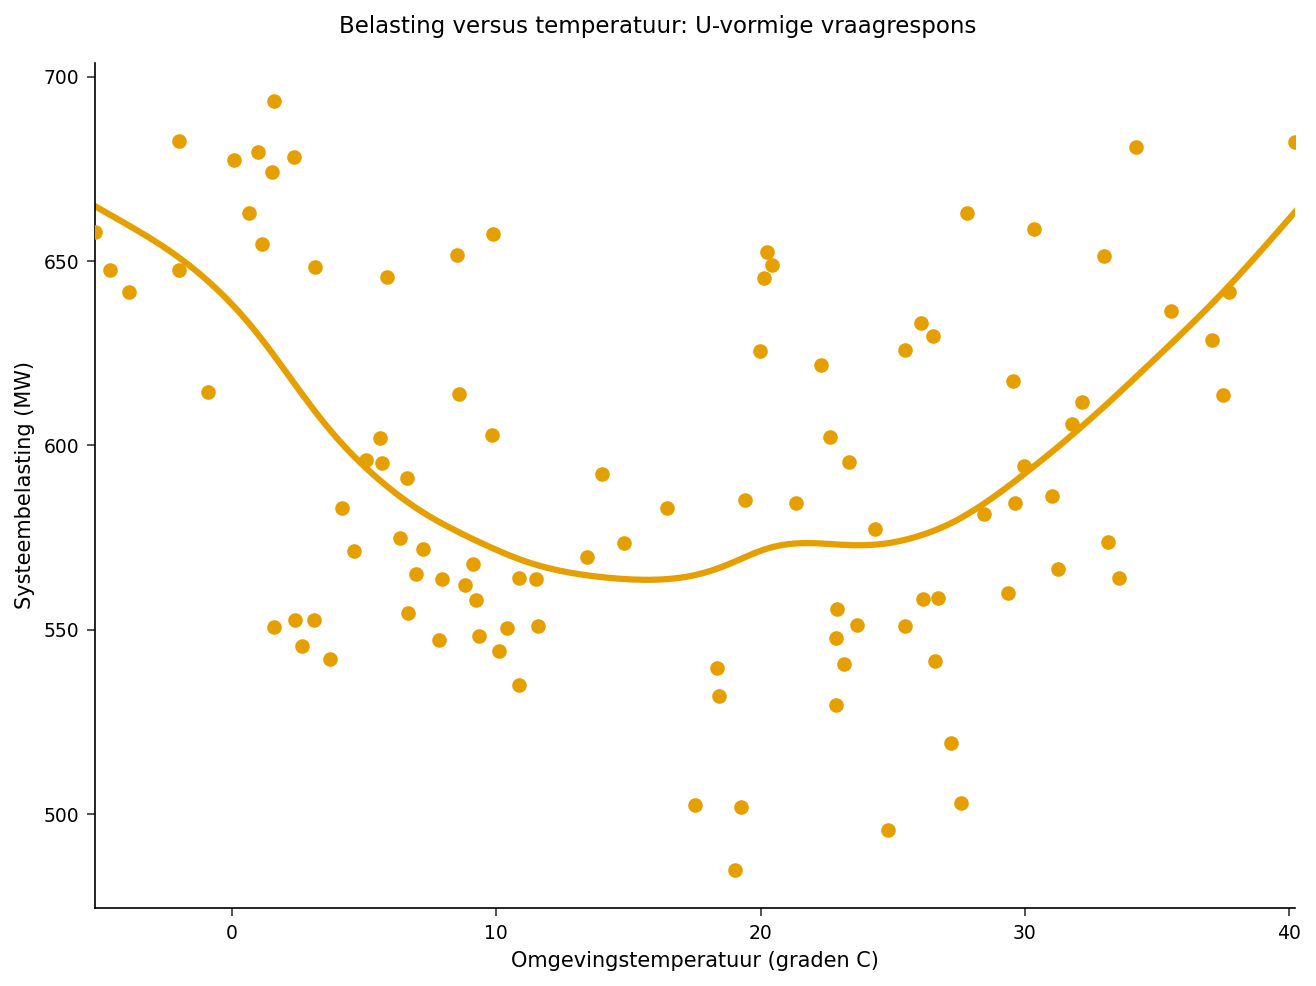

In [4]:
ODS GRAPHICS ON;

PROCEDURE SGPLOT GEGEVENS=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS label="Omgevingstemperatuur (graden C)";
   YAXIS label="Systeembelasting (MW)";
   TITEL "Belasting versus temperatuur: U-vormige vraagrespons";
UITVOEREN;

ODS GRAPHICS OFF;


## Stap 5 — Bevestig de U-vorm numeriek

De grafiek maakt de U-vorm zichtbaar; een gebande samenvatting maakt het kwantitatief. We verdelen waarnemingen in temperatuurbereiken en rapporteren de gemiddelde belasting per band. Als de vraagrespons werkelijk U-vormig is, zou de gemiddelde belasting hoog moeten zijn in de band **Koud**, dalen door **Koel / Comfortabel / Warm**, en weer stijgen in de band **Heet** — de numerieke signatuur die de smooth `s(TEMP_C)` van GAMPL oppikt.

In [5]:
GEGEVENS work.banded;
   INSTELLEN work.gridload;
   LENGTE tempband $16;
   ALS      temp_c <  5  DAN tempband = "1 Koud";
   ANDERS ALS temp_c < 15  DAN tempband = "2 Koel";
   ANDERS ALS temp_c < 22  DAN tempband = "3 Comfortabel";
   ANDERS ALS temp_c < 30  DAN tempband = "4 Warm";
   ANDERS                      tempband = "5 Heet";
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=work.banded n mean maxdec=1;
   KLASSE tempband;
   VARIABELE load_mw;
   label tempband="Temperatuurband" load_mw="Systeembelasting (MW)";
   TITEL "Gemiddelde belasting per temperatuurband";
UITVOEREN;


                                        Gemiddelde belasting per temperatuurband                                        

                                                  The MEANS Procedure

                                   Analysis Variable : load_mw Systeembelasting (MW)

        Temperatuurband          N Obs           Mean
        ---------------------------------------------
        1 Koud                      21          626.6
        2 Koel                      28          579.1
        3 Comfortabel               12          573.8
        4 Warm                      25          573.5
        5 Heet                      14          621.6
        ---------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretatie van de resultaten

**De smooths herstellen de fysica.** De tabel Smoothing Component van GAMPL kent de temperatuurterm `s(TEMP_C)` een effectieve DF van 5,53 toe (*p* < 0,0001) en de dagelijkse term `s(HOUR)` een EDF van 6,87 (*p* < 0,0001) — beide werkelijk gebogen, precies de structuur die we in de data hebben ingebouwd. De luchtvochtigheidsterm `s(HUMIDITY)` wordt teruggebracht tot EDF 1,00 (*p* = 0,07): de penalisatie strekt hem tot één bijna-lineaire vrijheidsgraad, omdat dat bij deze steekproefgrootte alles is wat de data ondersteunen. De parametrische schatting van `daytype` is −44,5 MW voor weekends, wat de verschuiving van 40 MW weekdagniveau in het genererende proces herstelt.

**Effectieve vrijheidsgraden vertellen het golvendheidsverhaal.** Het model besteedt in totaal 15,4 effectieve vrijheidsgraden en komt uit op een GCV-score van 239,6 (AIC 831,0, schaalschatting 202,7). Het begrenzen van `maxdf=` en het vastzetten van `df=3` in Stap 3 verandert de fit nauwelijks (GCV 240,1, EDF 15,47): de penalisatie had de temperatuur- en uursmooths al op eigen kracht rond 5,5 en 7 EDF vastgezet, dus de handmatige begrenzingen zijn hier niet-bindend — een teken dat de automatische selectie al conservatief was.

**De grafiek en de bandsamenvatting komen overeen.** Het spreidingsdiagram uit Stap 4 met zijn gepenaliseerde-spline-overlay toont dat de belasting daalt van het koude uiterste naar een minimum rond 15–20°C en weer stijgt richting de hitte. De bandgemiddelden van Stap 5 maken het numeriek: **Koud 626,6 MW**, **Koel 579,1**, **Comfortabel 573,8**, **Warm 573,5**, **Heet 621,6** — hoog aan beide uiteinden, laagst in het comfortabele midden. Die U is precies wat een enkele lineaire term `temp_c` zou wegmiddelen.

**Waarom GAMPL hier boven lineaire regressie.** Een enkele lineaire term `temp_c` zou de verwarmings- en koelregimes vermengen tot een bijna vlakke helling, met een slechte voorspelling van beide uitersten — precies de uren waarin netstress en prijspieken optreden. De additieve splineformulering behoudt de interpreteerbaarheid van een regressie (elke driver draagt een additief effect bij) terwijl de data de vorm van elk effect bepalen. Natuurlijke uitbreidingen voor een energiebedrijf omvatten een fit met `dist=gamma` als de belasting multiplicatief wordt gemodelleerd, een bivariate `spline(temp_c hour)` om vast te leggen hoe de dagelijkse piek verschuift met het seizoen, en `by`-verwerking om afzonderlijke modellen per onderstation te fitten.